# RiePCA on two weighted spherical clusters

The calculation is performed by the self-contained `riepca_manifold.py` module supplied with the paper.


## 0. Control panel

Every setting that is not part of the mathematics lives here.

`omega_a` discretizes the Riemannian volume measure `dV_g` in the field inner
product `sum_a omega_a g(U_a, V_a)`. This dataset yields **two** reference
points at every scale.

In the notebook, each reference point carries the same volume `REFERENCE_VOLUMES = 1`, so the field inner product is the counting measure on the reference set.

In [ ]:
import math
import numpy as np

# RiePCA fitting
MANIFOLD_DIMENSION = 2
#T_VALUES = np.asarray((0.04, 0.07, 0.10, 0.15, 0.20, 0.50, 1.0), dtype=float)
T_VALUES = np.asarray((0.15, 0.20, 0.50, 1.0), dtype=float)
TOP_K = 24
EIG_RTOL = 1.0e-12

# Reference selection
N_REFERENCES = 12
N_REFERENCE_SEEDS = 64
REFERENCE_STRATEGY = "smallest_t"
REFERENCE_VOLUMES = 1

## 1. Load the self-contained `riepca_manifold` module

Place `riepca_manifold.py` (or the supplied `riepca_manifold(6).py`) next to
this notebook. In Google Colab, the cell below asks you to upload that single
Python file if it is not already present. No wheel or unpublished package is
used.


In [ ]:
from pathlib import Path
import importlib.util
import subprocess
import sys


def find_riepca_manifold_file():
    candidates = [
        Path("riepca_manifold.py"),
        Path("riepca_manifold(6).py"),
        Path("/content/riepca_manifold.py"),
        Path("/content/riepca_manifold(6).py"),
    ]
    existing = [path for path in candidates if path.exists()]
    if existing:
        return existing[0]

    try:
        from google.colab import files
        uploaded = files.upload()
        uploaded_paths = [
            Path(name)
            for name in uploaded
            if Path(name).name.startswith("riepca_manifold")
            and Path(name).suffix == ".py"
        ]
        if uploaded_paths:
            return uploaded_paths[0]
    except ImportError:
        pass

    raise FileNotFoundError(
        "Place riepca_manifold.py next to this notebook or upload it in Colab."
    )


try:
    import geomstats
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "geomstats>=2.8,<3",
    ])
    import geomstats

RIEPCA_MANIFOLD_PATH = find_riepca_manifold_file()
spec = importlib.util.spec_from_file_location(
    "riepca_manifold_module",
    RIEPCA_MANIFOLD_PATH,
)
riepca_manifold_module = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = riepca_manifold_module
spec.loader.exec_module(riepca_manifold_module)

print("RiePCA manifold module:", RIEPCA_MANIFOLD_PATH.resolve())
print("Geomstats version:", geomstats.__version__)


RiePCA manifold module: /content/riepca_manifold.py
Geomstats version: 2.8.0


In [ ]:
import warnings
from pathlib import Path
from types import SimpleNamespace

import pandas as pd
import matplotlib.pyplot as plt

from geomstats.geometry.hypersphere import Hypersphere
from geomstats.learning.frechet_mean import FrechetMean
from geomstats.learning.pca import TangentPCA

from riepca_manifold_module import riepca_manifold, check_riepca

plt.style.use("default")


## 2. Synthetic two-cluster dataset on the unit sphere

The ambient space is $\mathbb{R}^3$, while the manifold is the **unit sphere**

$$
S^2=\{x\in\mathbb{R}^3:\lVert x\rVert=1\}.
$$

Thus, the sphere radius is $R=1$. It is implicit in
`Hypersphere(dim=2)`: Geomstats uses the unit hypersphere and therefore no
separate radius argument appears in the original code.

The dataset contains two independently sampled anisotropic Gaussian clouds in
the tangent planes at the north and south poles. The tangent vectors are mapped
to $S^2$ by the Riemannian exponential map. Because the sphere is unit radius,
the tangent standard deviations below are also angular scales in radians.

| property | cluster 0 | cluster 1 |
|---|---:|---:|
| generating center | (0,0,1) | (0.4,0,-0.6)/\|(0.4,0,-0.6)\| |
| number of points | 350 | 350 |
| probability mass | 0.30 | 0.70 |
| tangent std. dev. (radians) | (0.18, 0.10) | (0.24, 0.13) |
| tangent rotation (radians) | 0.40 | −0.50 |



In [ ]:
SPHERE_RADIUS = 1.0

DATASET_PATH = Path("sphere_two_weighted_clusters.npz")

if DATASET_PATH.exists():
    stored = np.load(DATASET_PATH)
    data_points = stored["data_points"]
    labels = stored["labels"]
    mu = stored["mu"]
    center_1 = stored["center_1"]
    center_2 = stored["center_2"]
    print("Loaded:", DATASET_PATH)
else:
    print("Dataset file not found; regenerating it.")

    rng = np.random.default_rng(42)
    sphere_for_generation = Hypersphere(dim=2)

    def normalize(point):
        point = np.asarray(point, dtype=float)
        return point / np.linalg.norm(point)

    def tangent_basis(center):
        center = normalize(center)

        trial = np.array([1.0, 0.0, 0.0])
        if abs(np.dot(trial, center)) > 0.8:
            trial = np.array([0.0, 1.0, 0.0])

        e1 = trial - np.dot(trial, center) * center
        e1 = e1 / np.linalg.norm(e1)

        e2 = np.cross(center, e1)
        e2 = e2 / np.linalg.norm(e2)
        return e1, e2

    def sample_spherical_cluster(
        center,
        n_samples,
        sigma_axes,
        tangent_rotation,
        rng,
    ):
        center = normalize(center)
        e1, e2 = tangent_basis(center)

        c = np.cos(tangent_rotation)
        s = np.sin(tangent_rotation)
        b1 = c * e1 + s * e2
        b2 = -s * e1 + c * e2

        z = rng.normal(size=(n_samples, 2))
        tangent_vectors = (
            sigma_axes[0] * z[:, 0, None] * b1
            + sigma_axes[1] * z[:, 1, None] * b2
        )

        base_points = np.broadcast_to(center, (n_samples, 3))
        return sphere_for_generation.metric.exp(
            tangent_vectors,
            base_points,
        )

    n_1 = 350
    n_2 = 350
    mass_1 = 0.30
    mass_2 = 0.70

    center_1 = normalize([0.00, 0.00, 1.00])
    center_2 = normalize([0.40, 0.00, -0.60])

    X_1 = sample_spherical_cluster(
        center_1,
        n_1,
        sigma_axes=(0.18, 0.10),
        tangent_rotation=0.40,
        rng=rng,
    )

    X_2 = sample_spherical_cluster(
        center_2,
        n_2,
        sigma_axes=(0.24, 0.13),
        tangent_rotation=-0.50,
        rng=rng,
    )

    data_points = np.vstack([X_1, X_2])
    labels = np.concatenate([
        np.zeros(n_1, dtype=int),
        np.ones(n_2, dtype=int),
    ])

    mu = np.concatenate([
        np.full(n_1, mass_1 / n_1),
        np.full(n_2, mass_2 / n_2),
    ])
    mu = mu / mu.sum()

    np.savez(
        DATASET_PATH,
        data_points=data_points,
        labels=labels,
        mu=mu,
        center_1=center_1,
        center_2=center_2,
    )
    print("Saved:", DATASET_PATH)

sphere = Hypersphere(dim=2)

print("Data shape:", data_points.shape)
print("All points on S^2:", bool(np.all(sphere.belongs(data_points))))
print("Total mass:", mu.sum())
print(
    "Cluster masses:",
    mu[labels == 0].sum(),
    mu[labels == 1].sum(),
)

point_norms = np.linalg.norm(data_points, axis=1)
center_dot_product = float(np.dot(center_1, center_2))

print("Sphere radius:", SPHERE_RADIUS)
print("Maximum radial error:", float(np.max(np.abs(point_norms - 1.0))))
print("Generating-center dot product:", center_dot_product)
print(
    "Generating centers exactly antipodal:",
    bool(np.allclose(center_2, -center_1)),
)


Loaded: sphere_two_weighted_clusters.npz
Data shape: (700, 3)
All points on S^2: True
Total mass: 1.0
Cluster masses: 0.29999999999999993 0.7000000000000002
Sphere radius: 1.0
Maximum radial error: 2.220446049250313e-16
Generating-center dot product: -0.8320502943378436
Generating centers exactly antipodal: False


## 3. Extrinsic and intrinsic means

The weighted Euclidean mean

$$
\bar x_{\mathrm{Euc}}=\sum_i\mu_i x_i
$$

usually lies inside the unit ball rather than on $S^2$.

The weighted Fréchet mean is

$$
\bar x_{\mathrm{Fr}}
=
\operatorname*{arg\,min}_{x\in S^2}
\sum_i\mu_i d_{S^2}(x,x_i)^2.
$$

In [ ]:
weights = mu / mu.sum()

weighted_euclidean_mean = np.sum(
    weights[:, None] * data_points,
    axis=0,
)

weighted_euclidean_mean_normalized = (
    weighted_euclidean_mean
    / np.linalg.norm(weighted_euclidean_mean)
)

unweighted_mean_estimator = FrechetMean(sphere)
unweighted_mean_estimator.fit(data_points)
unweighted_frechet_mean = unweighted_mean_estimator.estimate_

weighted_mean_estimator = FrechetMean(sphere)
weighted_mean_estimator.fit(data_points, weights=weights)
weighted_frechet_mean = weighted_mean_estimator.estimate_

print("Norm of weighted Euclidean mean:")
print(np.linalg.norm(weighted_euclidean_mean))

print("\nWeighted Euclidean mean:")
print(weighted_euclidean_mean)

print("\nNormalized weighted Euclidean mean:")
print(weighted_euclidean_mean_normalized)

print("\nUnweighted Fréchet mean:")
print(unweighted_frechet_mean)

print("\nWeighted Fréchet mean:")
print(weighted_frechet_mean)

print(
    "\nGeodesic distance between weighted Fréchet mean "
    "and normalized weighted Euclidean mean:"
)
print(
    float(
        sphere.metric.dist(
            weighted_frechet_mean,
            weighted_euclidean_mean_normalized,
        )
    )
)

Norm of weighted Euclidean mean:
0.4574663381239035

Weighted Euclidean mean:
[ 0.36846622 -0.00858453 -0.27098783]

Normalized weighted Euclidean mean:
[ 0.8054499  -0.01876539 -0.59236671]

Unweighted Fréchet mean:
[ 0.95463523 -0.07789956  0.2874078 ]

Weighted Fréchet mean:
[ 0.97186774 -0.07693495 -0.22260752]

Geodesic distance between weighted Fréchet mean and normalized weighted Euclidean mean:
0.41255402216008835


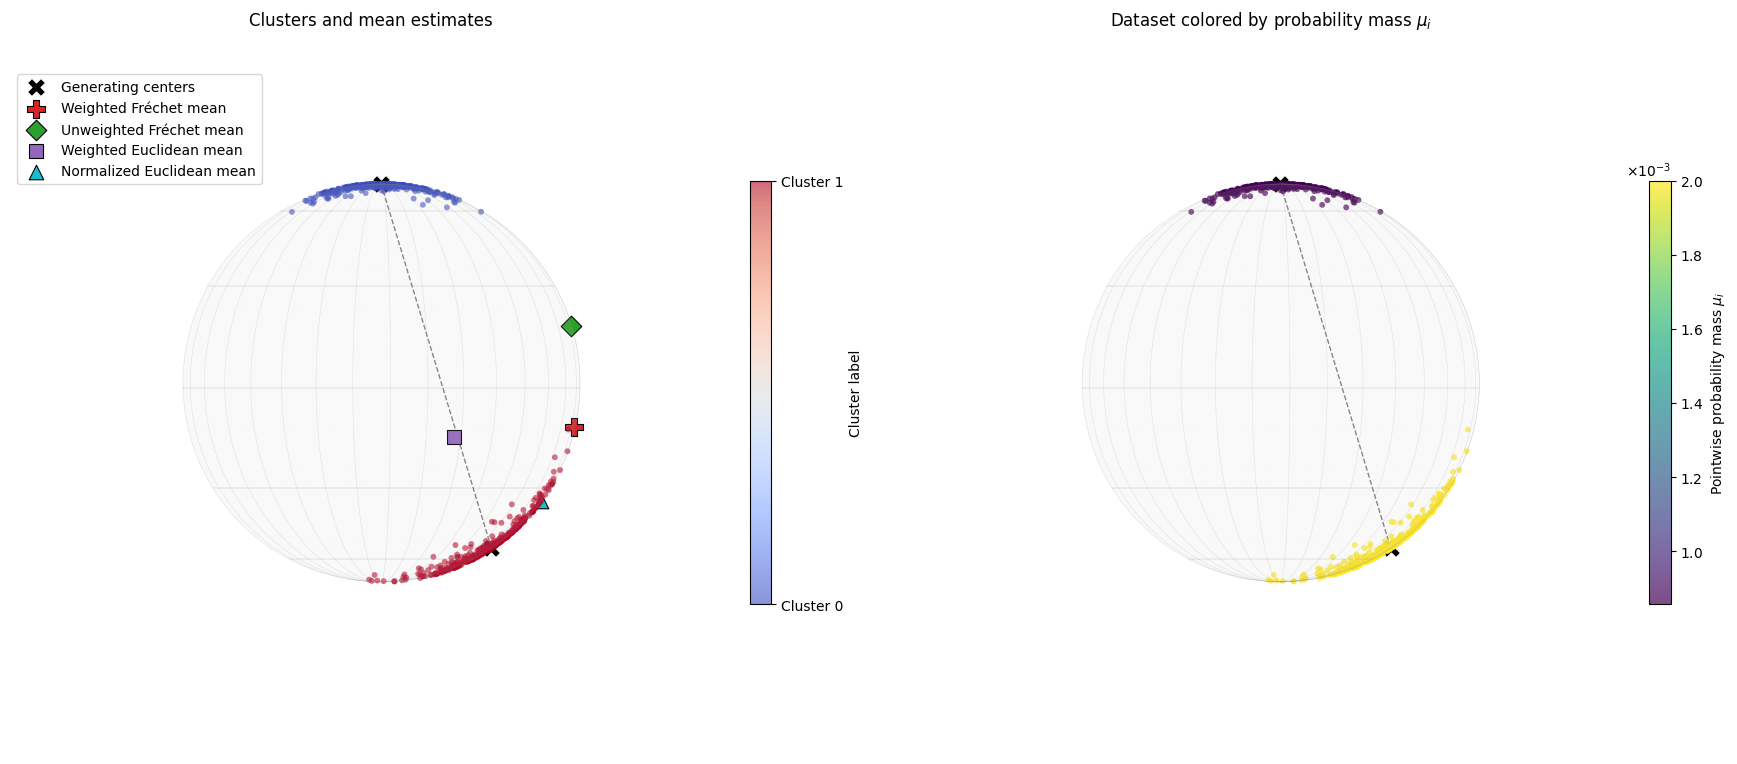

In [ ]:
from matplotlib.ticker import ScalarFormatter

SPHERE_VIEW_ELEV = 0
SPHERE_VIEW_AZIM = -90

u = np.linspace(0.0, 2.0 * np.pi, 100)
v = np.linspace(0.0, np.pi, 60)

sphere_x = SPHERE_RADIUS * np.outer(
    np.cos(u),
    np.sin(v),
)

sphere_y = SPHERE_RADIUS * np.outer(
    np.sin(u),
    np.sin(v),
)

sphere_z = SPHERE_RADIUS * np.outer(
    np.ones_like(u),
    np.cos(v),
)


def set_equal_3d_axes(
    ax,
    radius=SPHERE_RADIUS,
):
    limit = 1.08 * radius

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_box_aspect((1, 1, 1))


def draw_unit_sphere(ax):
    """Draw a faint explicit unit sphere."""

    ax.plot_surface(
        sphere_x,
        sphere_y,
        sphere_z,
        color="lightgray",
        alpha=0.05,
        linewidth=0,
        shade=False,
    )

    ax.plot_wireframe(
        sphere_x,
        sphere_y,
        sphere_z,
        rstride=6,
        cstride=10,
        color="gray",
        linewidth=0.35,
        alpha=0.22,
    )


def finish_sphere_axes(ax):
    """Apply equal scaling and remove the 3D background axes."""

    set_equal_3d_axes(ax)

    ax.set_proj_type("ortho")

    ax.view_init(
        elev=SPHERE_VIEW_ELEV,
        azim=SPHERE_VIEW_AZIM,
    )

    ax.grid(False)
    ax.set_axis_off()


def draw_generating_centers(
    ax,
    include_label=False,
):
    """Draw the chord between the generating centers and the centers."""

    ax.plot(
        [center_1[0], center_2[0]],
        [center_1[1], center_2[1]],
        [center_1[2], center_2[2]],
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.5,
    )

    ax.scatter(
        [center_1[0], center_2[0]],
        [center_1[1], center_2[1]],
        [center_1[2], center_2[2]],
        color="black",
        marker="X",
        s=170,
        edgecolor="white",
        linewidth=0.8,
        depthshade=False,
        label=(
            "Generating centers"
            if include_label
            else None
        ),
    )


fig = plt.figure(
    figsize=(18, 8),
)

ax_labels = fig.add_subplot(
    1,
    2,
    1,
    projection="3d",
)

ax_mu = fig.add_subplot(
    1,
    2,
    2,
    projection="3d",
)


# Left panel: observations colored by cluster label
draw_unit_sphere(ax_labels)

label_scatter = ax_labels.scatter(
    data_points[:, 0],
    data_points[:, 1],
    data_points[:, 2],
    c=labels,
    cmap="coolwarm",
    s=18,
    alpha=0.60,
    edgecolor="none",
    depthshade=False,
)

draw_generating_centers(
    ax_labels,
    include_label=True,
)

ax_labels.scatter(
    weighted_frechet_mean[0],
    weighted_frechet_mean[1],
    weighted_frechet_mean[2],
    color="tab:red",
    marker="P",
    s=180,
    edgecolor="black",
    linewidth=0.8,
    depthshade=False,
    label="Weighted Fréchet mean",
)

ax_labels.scatter(
    unweighted_frechet_mean[0],
    unweighted_frechet_mean[1],
    unweighted_frechet_mean[2],
    color="tab:green",
    marker="D",
    s=110,
    edgecolor="black",
    linewidth=0.8,
    depthshade=False,
    label="Unweighted Fréchet mean",
)

ax_labels.scatter(
    weighted_euclidean_mean[0],
    weighted_euclidean_mean[1],
    weighted_euclidean_mean[2],
    color="tab:purple",
    marker="s",
    s=100,
    edgecolor="black",
    linewidth=0.8,
    depthshade=False,
    label="Weighted Euclidean mean",
)

ax_labels.scatter(
    weighted_euclidean_mean_normalized[0],
    weighted_euclidean_mean_normalized[1],
    weighted_euclidean_mean_normalized[2],
    color="tab:cyan",
    marker="^",
    s=110,
    edgecolor="black",
    linewidth=0.8,
    depthshade=False,
    label="Normalized Euclidean mean",
)

label_values = np.unique(labels)

label_colorbar = fig.colorbar(
    label_scatter,
    ax=ax_labels,
    ticks=label_values,
    shrink=0.55,
    pad=0.02,
)

label_colorbar.set_label(
    "Cluster label"
)

label_colorbar.ax.set_yticklabels([
    f"Cluster {label}"
    for label in label_values
])

ax_labels.set_title(
    "Clusters and mean estimates",
    pad=4,
)

finish_sphere_axes(ax_labels)

ax_labels.legend(
    loc="upper left",
    frameon=True,
    bbox_to_anchor=(0.0, 0.95),
)


# Right panel: observations colored by pointwise mass mu_i
draw_unit_sphere(ax_mu)

mu_scatter = ax_mu.scatter(
    data_points[:, 0],
    data_points[:, 1],
    data_points[:, 2],
    c=mu,
    cmap="viridis",
    s=18,
    alpha=0.70,
    edgecolor="none",
    depthshade=False,
)

draw_generating_centers(
    ax_mu,
    include_label=False,
)

mu_formatter = ScalarFormatter(
    useMathText=True
)

mu_formatter.set_powerlimits(
    (0, 0)
)

mu_colorbar = fig.colorbar(
    mu_scatter,
    ax=ax_mu,
    shrink=0.55,
    pad=0.02,
    format=mu_formatter,
)

mu_colorbar.set_label(
    r"Pointwise probability mass $\mu_i$"
)

mu_colorbar.update_ticks()

ax_mu.set_title(
    r"Dataset colored by probability mass $\mu_i$",
    pad=4,
)

finish_sphere_axes(ax_mu)


plt.tight_layout()
plt.show()

## 4. Manifold RiePCA using `riepca_manifold`

The standalone module constructs the geodesic-Gaussian field: for each reference point $x$,
$$
F_{y}(x)=\frac{(4\pi t)^{-q/2}}{2t}
\exp(-\frac{d(x,y)^2}{4t})\operatorname{Log}_x(y).
$$

In [ ]:
# Generates approximately uniform starting points for the local optimizer
def _fibonacci_sphere(count):
    index = np.arange(count, dtype=float)
    z = 1.0 - 2.0 * (index + 0.5) / count
    radius = np.sqrt(np.maximum(1.0 - z * z, 0.0))
    phi = np.pi * (3.0 - np.sqrt(5.0)) * index
    return np.column_stack([radius * np.cos(phi), radius * np.sin(phi), z])


def _pairwise_sphere_distance_squared(points, references):
    cosine = np.clip(np.asarray(points) @ np.asarray(references).T, -1.0, 1.0)
    return np.arccos(cosine) ** 2


def _lexicographic_choice(points, indices):
    indices = np.asarray(indices, dtype=int)
    return int(min(indices, key=lambda i: tuple(np.asarray(points[i]).tolist())))


def _farthest_indices(points, count, start_index):
    selected = [int(start_index)]
    minimum_distance = _pairwise_sphere_distance_squared(
        points,
        points[[start_index]],
    )[:, 0]
    while len(selected) < min(count, len(points)):
        minimum_distance[selected] = -np.inf
        best = float(np.max(minimum_distance))
        ties = np.flatnonzero(np.isclose(minimum_distance, best, rtol=1e-12, atol=0.0))
        index = int(ties[0]) if ties.size == 1 else _lexicographic_choice(points, ties)
        selected.append(index)
        distance = _pairwise_sphere_distance_squared(points, points[[index]])[:, 0]
        minimum_distance = np.minimum(minimum_distance, distance)
    return np.asarray(selected, dtype=int)


def _sphere_exp(tangent_vector, base_point):
    return np.asarray(
        sphere.metric.exp(tangent_vector, base_point=base_point),
        dtype=float,
    )


def _density_and_gradient(point, points, weights, t):
    """Weighted geodesic-Gaussian density and gradient on S^2."""
    point = np.asarray(point, dtype=float)
    points = np.asarray(points, dtype=float)
    weights = np.asarray(weights, dtype=float)

    t = float(t)
    if not np.isfinite(t) or t <= 0.0:
        raise ValueError("t must be finite and positive.")

    distance_squared = _pairwise_sphere_distance_squared(
        points,
        point[None, :],
    )[:, 0]

    kernel = (
        np.exp(-distance_squared / (4.0 * t))
        / (4.0 * np.pi * t)
    )

    # Some Geomstats versions do not broadcast metric.log.
    try:
        logs = np.asarray(sphere.metric.log(points, base_point=point),dtype=float,)
        if logs.shape != points.shape:
            raise ValueError("Unexpected batched logarithm shape.")
    except Exception:
        logs = np.stack(
            [
                np.asarray(
                    sphere.metric.log(y, base_point=point),
                    dtype=float,
                )
                for y in points
            ],
            axis=0,
        )

    individual_gradients = (kernel / (2.0 * t))[:, None] * logs

    return (float(kernel @ weights),np.tensordot(weights, individual_gradients, axes=(0, 0)),)


def _refine_sphere_mode(start, points, weights, t):
    current = np.asarray(start, dtype=float).copy()
    density, gradient = _density_and_gradient(current, points, weights, t)
    for _ in range(100):
        direction = gradient / max(density, np.finfo(float).tiny)
        norm_sq = float(sphere.metric.inner_product(direction, direction, base_point=current))
        if not np.isfinite(norm_sq) or norm_sq <= 1.0e-12:
            break
        step = 1.0
        accepted = False
        for _ in range(31):
            candidate = _sphere_exp(step * direction, current)
            candidate_density, candidate_gradient = _density_and_gradient(
                candidate, points, weights, t
            )
            if np.isfinite(candidate_density) and candidate_density >= density:
                current = candidate
                density = candidate_density
                gradient = candidate_gradient
                accepted = True
                break
            step *= 0.5
        if not accepted:
            break
    return current, density


def select_smallest_time_references(points, weights, t, n_references=12, n_seeds=64):
    points = np.asarray(points, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    support = np.flatnonzero(weights > 0.0)
    support_points = points[support]
    support_weights = weights[support] / weights[support].sum()

    n_uniform = max(1, n_seeds // 2)
    n_data = max(0, n_seeds - n_uniform)
    uniform_seeds = _fibonacci_sphere(n_uniform)

    mean_estimator = FrechetMean(sphere)
    mean_estimator.fit(support_points, weights=support_weights)
    center = np.asarray(mean_estimator.estimate_, dtype=float)
    distances = _pairwise_sphere_distance_squared(support_points, center[None, :])[:, 0]
    minimum = float(np.min(distances))
    tolerance = 32.0 * np.finfo(float).eps * max(1.0, abs(minimum))
    ties = np.flatnonzero(np.abs(distances - minimum) <= tolerance)
    start = _lexicographic_choice(support_points, ties)
    data_seed_indices = _farthest_indices(
        support_points,
        min(n_data, len(support_points)),
        start,
    )
    seeds = np.concatenate([uniform_seeds, support_points[data_seed_indices]], axis=0)

    maximum = float(np.max(support_weights))
    weight_ties = np.flatnonzero(np.isclose(support_weights, maximum, rtol=0.0, atol=0.0))
    anchor = support_points[_lexicographic_choice(support_points, weight_ties)]
    anchor_distances = _pairwise_sphere_distance_squared(
        support_points, anchor[None, :]
    )[:, 0]
    merge_tolerance = 1.0e-3 * np.sqrt(
        max(float(support_weights @ anchor_distances), np.finfo(float).tiny)
    )

    modes = []
    densities = []
    for seed in seeds:
        mode, density = _refine_sphere_mode(seed, points, weights, float(t))
        duplicate = next(
            (
                j for j, existing in enumerate(modes)
                if _pairwise_sphere_distance_squared(
                    mode[None, :], existing[None, :]
                )[0, 0] <= merge_tolerance ** 2
            ),
            None,
        )
        if duplicate is None:
            modes.append(mode)
            densities.append(density)
        elif density > densities[duplicate]:
            modes[duplicate] = mode
            densities[duplicate] = density

    order = np.argsort(densities)[::-1][:n_references]
    return np.asarray([modes[i] for i in order], dtype=float)


# Multiscale adapter keyed only by absolute diffusion time t
reference_points = select_smallest_time_references(
    data_points,
    weights,
    float(np.min(T_VALUES)),
    n_references=N_REFERENCES,
    n_seeds=N_REFERENCE_SEEDS,
)

reference_volumes = np.full(reference_points.shape[0], float(REFERENCE_VOLUMES))

by_t = {}
for t in T_VALUES:
    t = float(t)
    result_at_time = riepca_manifold(
        data_points,
        reference_points,
        sphere,
        t=t,
        mu=weights,
        reference_volumes=reference_volumes,
        manifold_dimension=MANIFOLD_DIMENSION,
        k_keep=TOP_K,
        eig_rtol=EIG_RTOL,
    )
    check_riepca(result_at_time, sphere)
    by_t[t] = result_at_time

riepca_result = SimpleNamespace(
    t_values=[float(value) for value in T_VALUES],
    reference_points_dict={t: value.reference_points for t, value in by_t.items()},
    reference_volumes_dict={t: value.reference_volumes for t, value in by_t.items()},
    evals_dict={t: value.eigenvalues for t, value in by_t.items()},
    pc_fields_dict={t: value.pc_fields for t, value in by_t.items()},
    mean_field_dict={t: value.mean_field for t, value in by_t.items()},
    projections_dict={t: value.scores for t, value in by_t.items()},
    total_var_dict={t: value.total_variance for t, value in by_t.items()},
    explained_variance_ratio_dict={
        t: value.explained_variance_ratio for t, value in by_t.items()
    },
    cumulative_explained_variance_ratio_dict={
        t: value.cumulative_explained_variance_ratio for t, value in by_t.items()
    },
    by_time=by_t,
)

reference_counts = {
    t: riepca_result.reference_points_dict[t].shape[0]
    for t in riepca_result.t_values
}

print("References per diffusion time:", reference_counts)
print("\nRiePCA diffusion times t:")
print(riepca_result.t_values)
print("\nRiePCA results:")
for t in riepca_result.t_values:
    print(
        f"t={t:g}: "
        f"{len(riepca_result.evals_dict[t])} retained components, "
        f"cumulative EVR="
        f"{riepca_result.cumulative_explained_variance_ratio_dict[t][-1]:.6f}"
    )


References per diffusion time: {0.15: 2, 0.2: 2, 0.5: 2, 1.0: 2}

RiePCA diffusion times t:
[0.15, 0.2, 0.5, 1.0]

RiePCA results:
t=0.15: 4 retained components, cumulative EVR=1.000000
t=0.2: 4 retained components, cumulative EVR=1.000000
t=0.5: 4 retained components, cumulative EVR=1.000000
t=1: 4 retained components, cumulative EVR=1.000000


## 5. Eigenvalue spectra and cumulative explained variance

Explained-variance proportions are meaningful for RiePCA construction.

When there are exactly two references on $S^2$ for a time $t$, the field space $\bigoplus_a T_{x_a}S^2$ has dimension $r\cdot q = 4$ ($q=2$ because $S^2$ is a $2$-dimensional manifold), hence there are exactly four components exist such a $t$ and cumulative explained variance reaches $1$ at PC4 by construction.

RiePCA diffusion times t:
[0.15, 0.2, 0.5, 1.0]


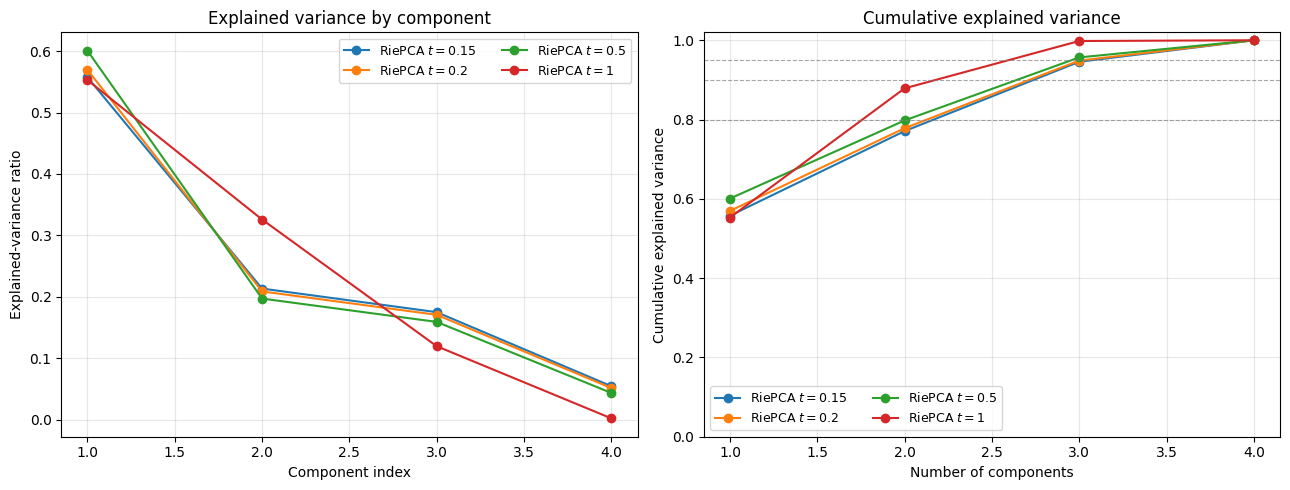

In [ ]:
def cumulative_from_eigenvalues(eigenvalues):
    eigenvalues = np.asarray(eigenvalues, dtype=float)
    total = float(np.sum(eigenvalues))

    if total <= 0:
        return np.full_like(eigenvalues, np.nan)

    return np.cumsum(eigenvalues / total)


print("RiePCA diffusion times t:")
print(riepca_result.t_values)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)


# Panel 1: explained variance by component
for t in riepca_result.t_values:
    explained = (
        riepca_result
        .explained_variance_ratio_dict[t]
    )

    axes[0].plot(
        np.arange(1, len(explained) + 1),
        explained,
        marker="o",
        label=rf"RiePCA $t={t:g}$",
    )

axes[0].set_xlabel("Component index")
axes[0].set_ylabel("Explained-variance ratio")
axes[0].set_title("Explained variance by component")
axes[0].grid(alpha=0.3)
axes[0].legend(
    fontsize=9,
    ncol=2,
)


# Panel 2: cumulative explained variance
for t in riepca_result.t_values:
    cumulative = (
        riepca_result
        .cumulative_explained_variance_ratio_dict[t]
    )

    axes[1].plot(
        np.arange(1, len(cumulative) + 1),
        cumulative,
        marker="o",
        label=rf"RiePCA $t={t:g}$",
    )

for threshold in (0.80, 0.90, 0.95):
    axes[1].axhline(
        threshold,
        linewidth=0.8,
        linestyle="--",
        color="gray",
        alpha=0.7,
    )

axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_ylim(0.0, 1.02)
axes[1].set_title("Cumulative explained variance")
axes[1].grid(alpha=0.3)
axes[1].legend(
    fontsize=9,
    ncol=2,
)

plt.tight_layout()
plt.show()

## 6. Projection of the dataset into 2-dimensional eigenspaces

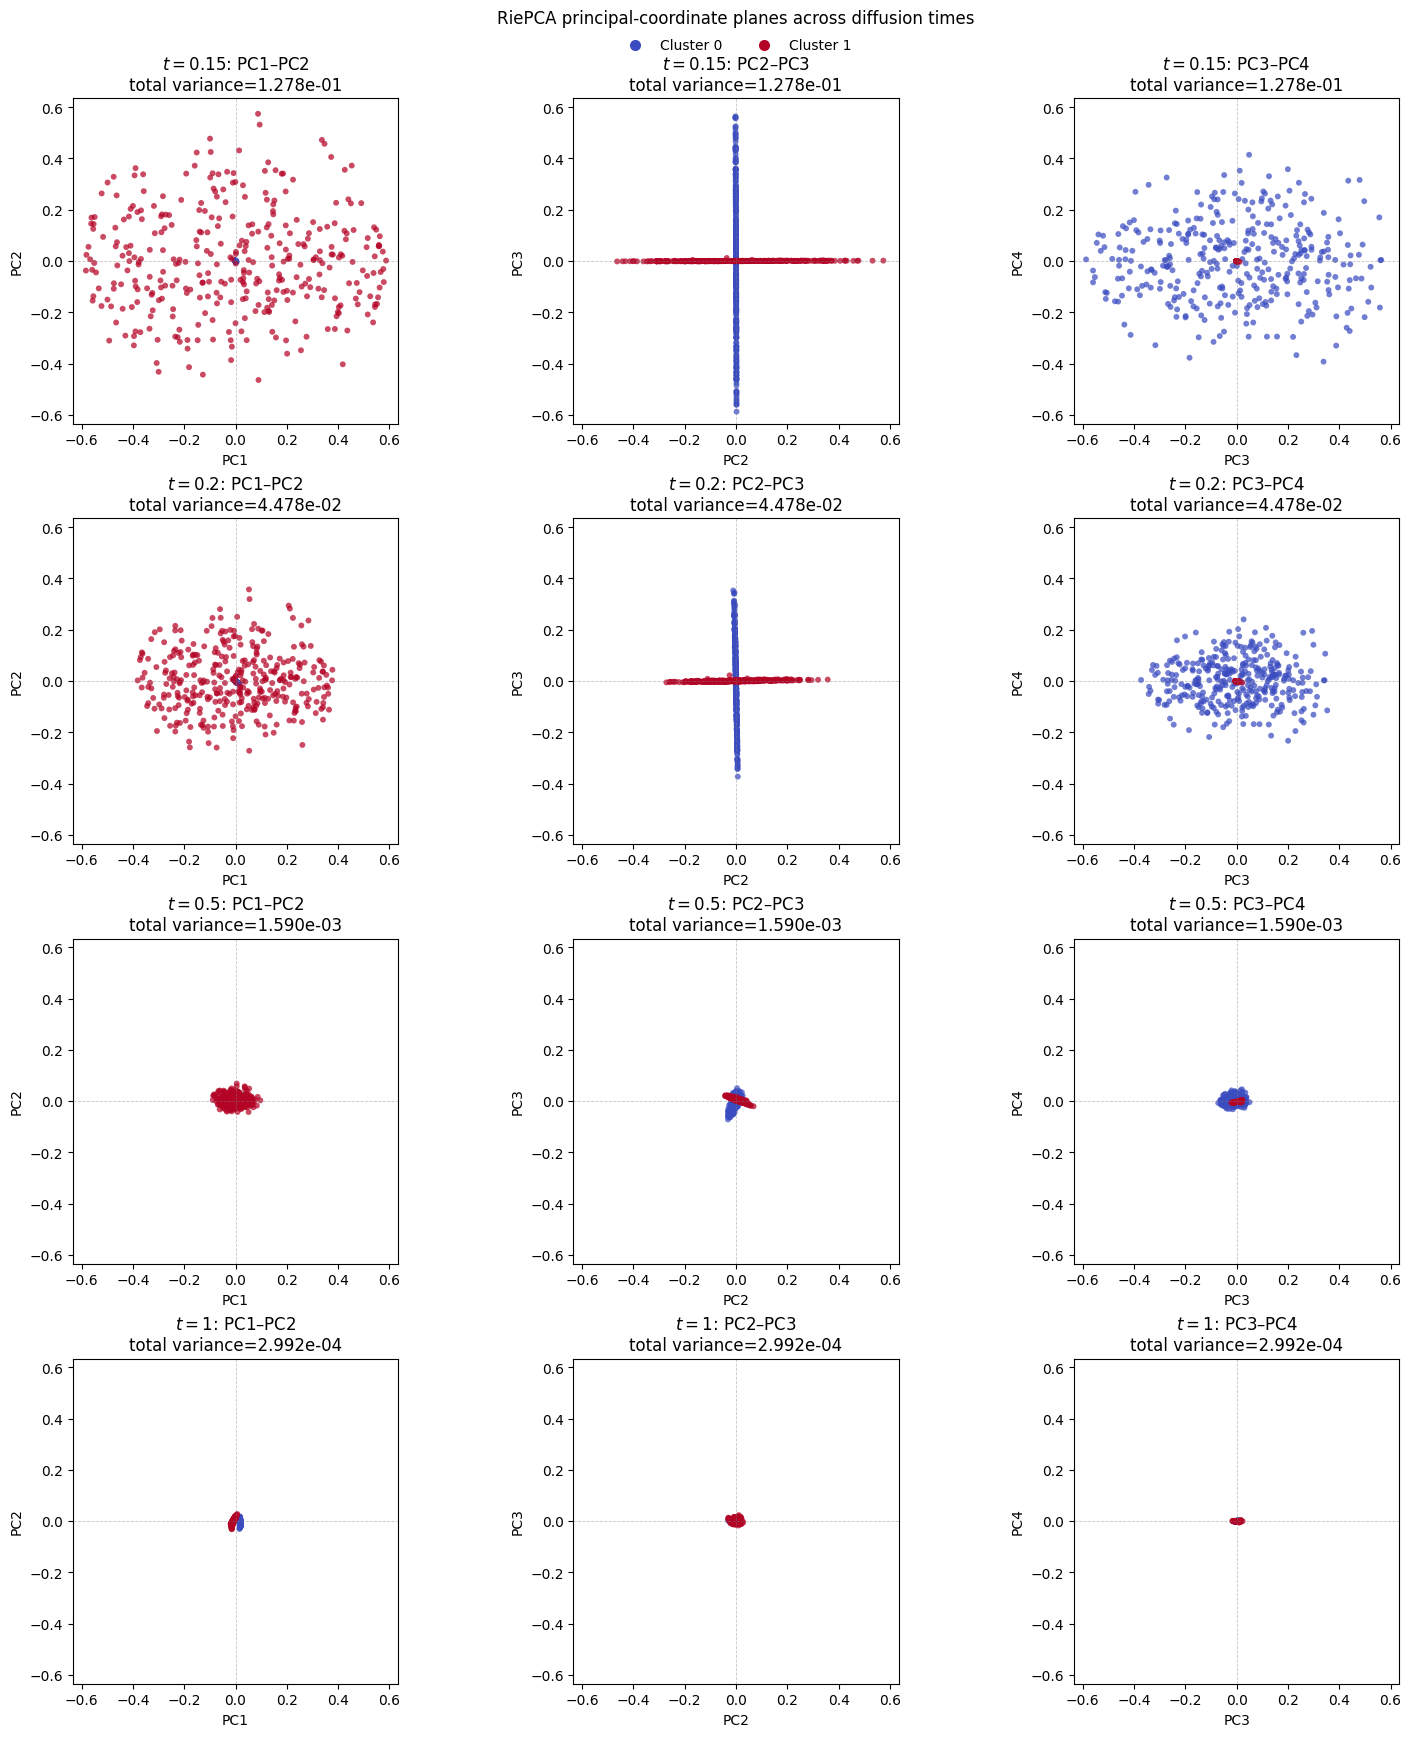

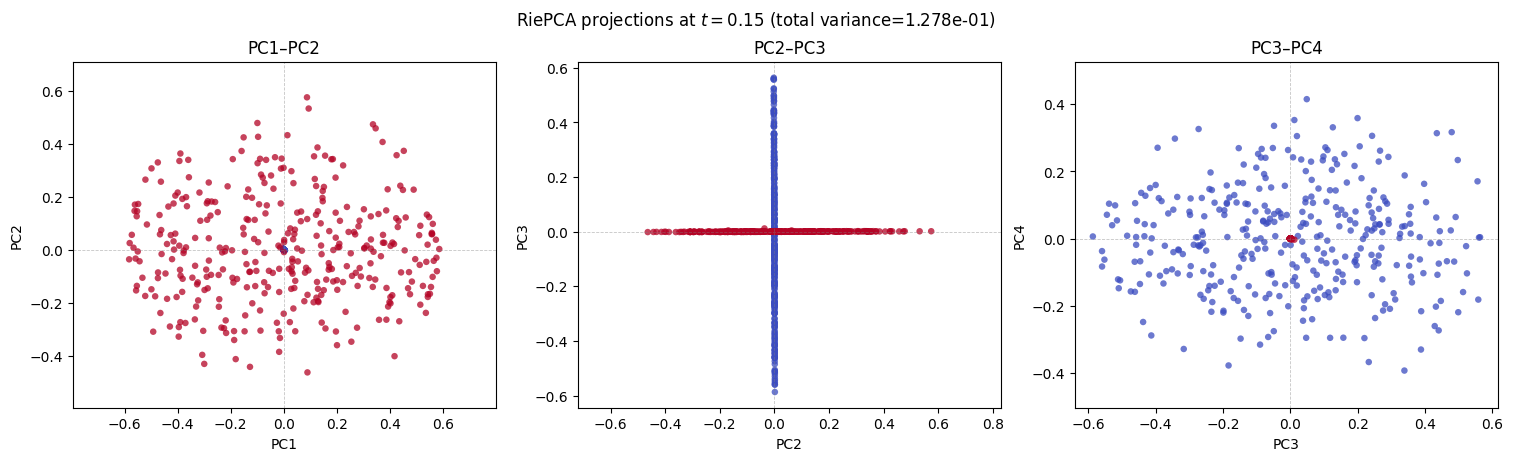

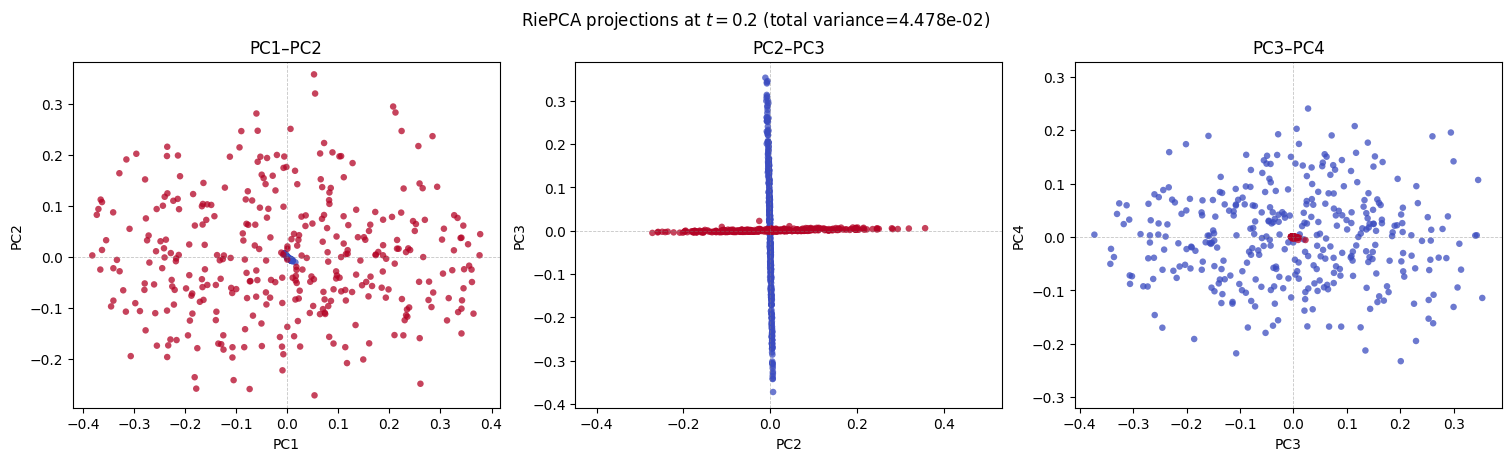

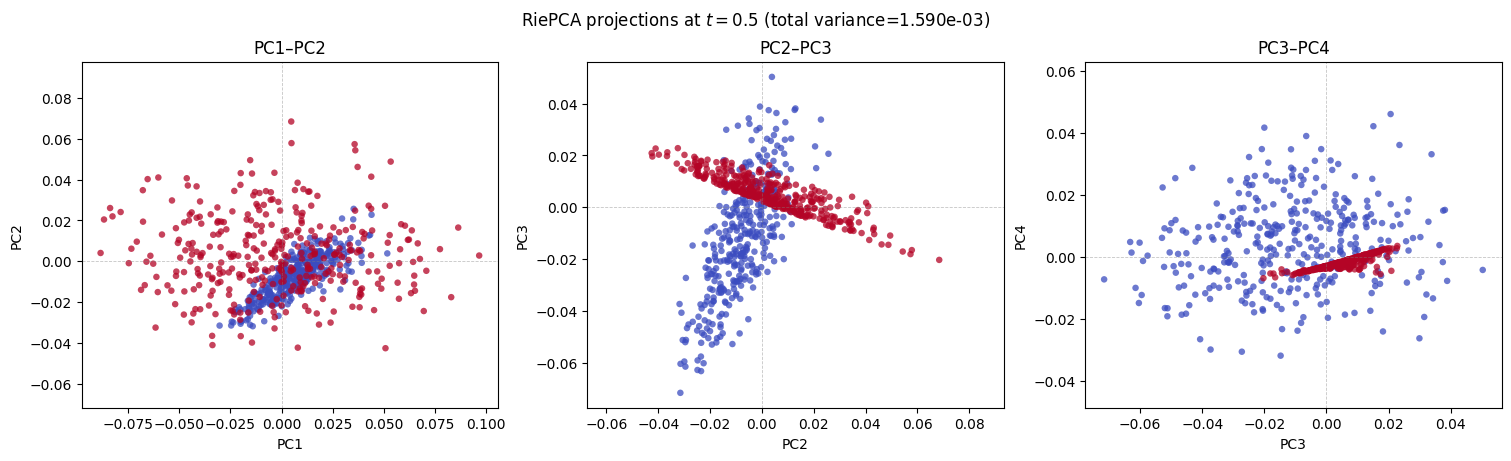

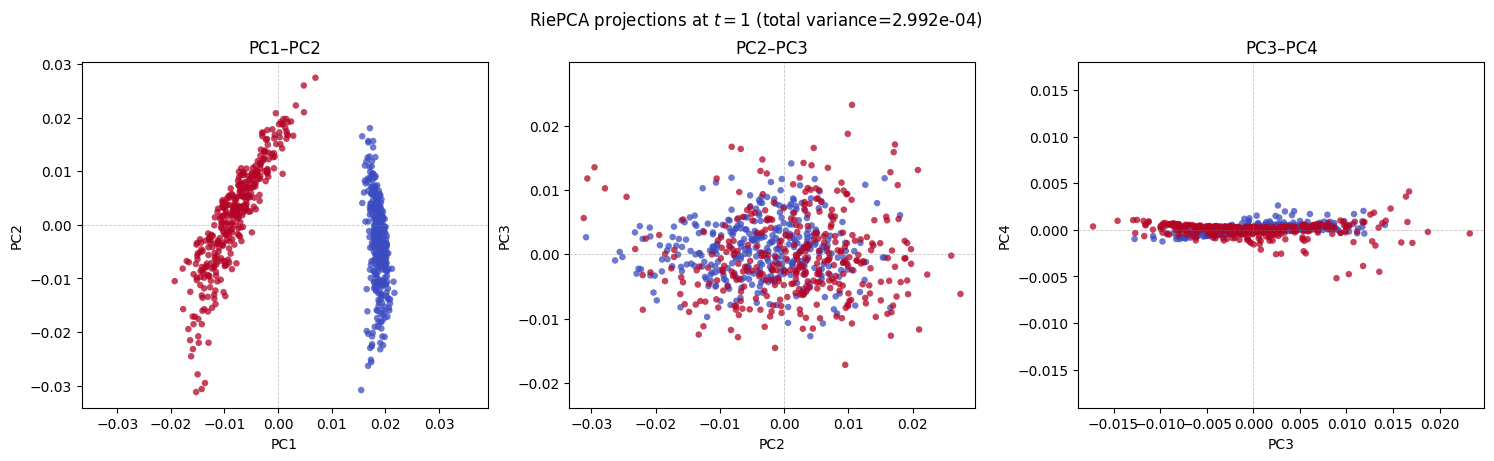

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def get_riepca_time_entries(result):
    """Return absolute diffusion time t and its projection matrix."""
    return [
        (
            float(t),
            np.asarray(result.projections_dict[t], dtype=float),
        )
        for t in result.t_values
    ]


# Figure 1: all diffusion times in one multirow figure
def plot_pc_planes_for_all_times(
    result,
    labels,
    pairs=((0, 1), (1, 2), (2, 3)),
    fixed_axes=True,
):
    labels = np.asarray(labels)
    time_entries = get_riepca_time_entries(result)

    # Compute one fixed symmetric limit for each PC plane.
    # This permits direct comparison across diffusion times.
    pair_limits = {}

    for i, j in pairs:
        maximum_absolute_coordinate = 0.0

        for _, projection in time_entries:
            if projection.shape[1] <= max(i, j):
                continue

            coordinates = projection[:, [i, j]]

            maximum_absolute_coordinate = max(
                maximum_absolute_coordinate,
                float(np.max(np.abs(coordinates))),
            )

        pair_limits[(i, j)] = (
            1.08 * maximum_absolute_coordinate
            if maximum_absolute_coordinate > 0.0
            else 1.0
        )

    n_rows = len(time_entries)
    n_cols = len(pairs)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(
            5.0 * n_cols,
            4.2 * n_rows,
        ),
        squeeze=False,
        constrained_layout=True,
    )

    unique_labels = np.unique(labels)
    cmap = plt.cm.coolwarm

    label_min = float(np.min(unique_labels))
    label_max = float(np.max(unique_labels))

    if label_max == label_min:
        label_max = label_min + 1.0

    for row, (t, projection) in enumerate(time_entries):
        eigenvalues = np.asarray(
            result.evals_dict[t],
            dtype=float,
        )

        total_variance = float(result.by_time[t].total_variance)

        for col, (i, j) in enumerate(pairs):
            ax = axes[row, col]

            if projection.shape[1] <= max(i, j):
                ax.text(
                    0.5,
                    0.5,
                    f"PC{max(i, j) + 1} not available",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )

                ax.set_axis_off()
                continue

            coordinates = projection[:, [i, j]]

            ax.scatter(
                coordinates[:, 0],
                coordinates[:, 1],
                c=labels,
                cmap=cmap,
                vmin=label_min,
                vmax=label_max,
                s=18,
                alpha=0.72,
                edgecolors="none",
            )

            ax.axhline(
                0.0,
                color="gray",
                linewidth=0.6,
                linestyle="--",
                alpha=0.45,
            )

            ax.axvline(
                0.0,
                color="gray",
                linewidth=0.6,
                linestyle="--",
                alpha=0.45,
            )

            if fixed_axes:
                limit = pair_limits[(i, j)]

                ax.set_xlim(-limit, limit)
                ax.set_ylim(-limit, limit)

                ax.set_aspect(
                    "equal",
                    adjustable="box",
                )
            else:
                ax.set_aspect(
                    "equal",
                    adjustable="datalim",
                )

            ax.set_xlabel(f"PC{i + 1}")
            ax.set_ylabel(f"PC{j + 1}")

            ax.set_title(
                f"$t={t:g}$: "
                f"PC{i + 1}–PC{j + 1}\n"
                f"total variance={total_variance:.3e}"
            )

            ax.grid(False)

    # Discrete cluster legend.
    legend_handles = []

    for label_value in unique_labels:
        normalized_value = (
            float(label_value) - label_min
        ) / (
            label_max - label_min
        )

        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=cmap(
                    normalized_value
                ),
                markeredgecolor="none",
                markersize=8,
                label=f"Cluster {label_value}",
            )
        )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=len(unique_labels),
        frameon=False,
        bbox_to_anchor=(0.5, 1.015),
    )

    fig.suptitle(
        "RiePCA principal-coordinate planes across diffusion times",
        y=1.025,
    )

    plt.show()


plot_pc_planes_for_all_times(
    riepca_result,
    labels,
    pairs=(
        (0, 1),  # PC1–PC2
        (1, 2),  # PC2–PC3
        (2, 3),  # PC3–PC4
    ),
    fixed_axes=True,
)


# Figure 2: one figure for each diffusion time
def plot_pc_planes_one_row_per_time(
    result,
    labels,
    pairs=((0, 1), (1, 2), (2, 3)),
    fixed_axes=True,
):
    labels = np.asarray(labels)
    time_entries = get_riepca_time_entries(result)

    # Fixed limits for each PC plane across all diffusion times.
    pair_limits = {}

    for i, j in pairs:
        maximum_absolute_coordinate = 0.0

        for _, projection in time_entries:
            if projection.shape[1] <= max(i, j):
                continue

            coordinates = projection[:, [i, j]]

            maximum_absolute_coordinate = max(
                maximum_absolute_coordinate,
                float(np.max(np.abs(coordinates))),
            )

        pair_limits[(i, j)] = (
            1.08 * maximum_absolute_coordinate
            if maximum_absolute_coordinate > 0.0
            else 1.0
        )

    label_min = float(np.min(labels))
    label_max = float(np.max(labels))

    if label_min == label_max:
        label_max = label_min + 1.0

    for t, projection in time_entries:
        eigenvalues = np.asarray(
            result.evals_dict[t],
            dtype=float,
        )

        total_variance = float(
            np.sum(eigenvalues)
        )

        fig, axes = plt.subplots(
            1,
            len(pairs),
            figsize=(15, 4.5),
            constrained_layout=True,
        )

        axes = np.atleast_1d(axes)

        for ax, (i, j) in zip(
            axes,
            pairs,
        ):
            if projection.shape[1] <= max(i, j):
                ax.text(
                    0.5,
                    0.5,
                    f"PC{max(i, j) + 1} unavailable",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )

                ax.set_axis_off()
                continue

            coordinates = projection[:, [i, j]]

            ax.scatter(
                coordinates[:, 0],
                coordinates[:, 1],
                c=labels,
                cmap="coolwarm",
                vmin=label_min,
                vmax=label_max,
                s=22,
                alpha=0.75,
                edgecolors="none",
            )

            ax.axhline(
                0.0,
                color="gray",
                linewidth=0.6,
                linestyle="--",
                alpha=0.45,
            )

            ax.axvline(
                0.0,
                color="gray",
                linewidth=0.6,
                linestyle="--",
                alpha=0.45,
            )

            if fixed_axes:
                limit = pair_limits[(i, j)]

                ax.set_xlim(-limit, limit)
                ax.set_ylim(-limit, limit)

                ax.set_aspect(
                    "equal",
                    adjustable="box",
                )
            else:
                ax.set_aspect(
                    "equal",
                    adjustable="datalim",
                )

            ax.set_xlabel(f"PC{i + 1}")
            ax.set_ylabel(f"PC{j + 1}")
            ax.set_title(
                f"PC{i + 1}–PC{j + 1}"
            )
            ax.grid(False)

        fig.suptitle(
            f"RiePCA projections at $t={t:g}$ "
            f"(total variance={total_variance:.3e})"
        )

        plt.show()


plot_pc_planes_one_row_per_time(
    riepca_result,
    labels,
    pairs=(
        (0, 1),
        (1, 2),
        (2, 3),
    ),
    fixed_axes=False,
)

# Generate figures for the paper

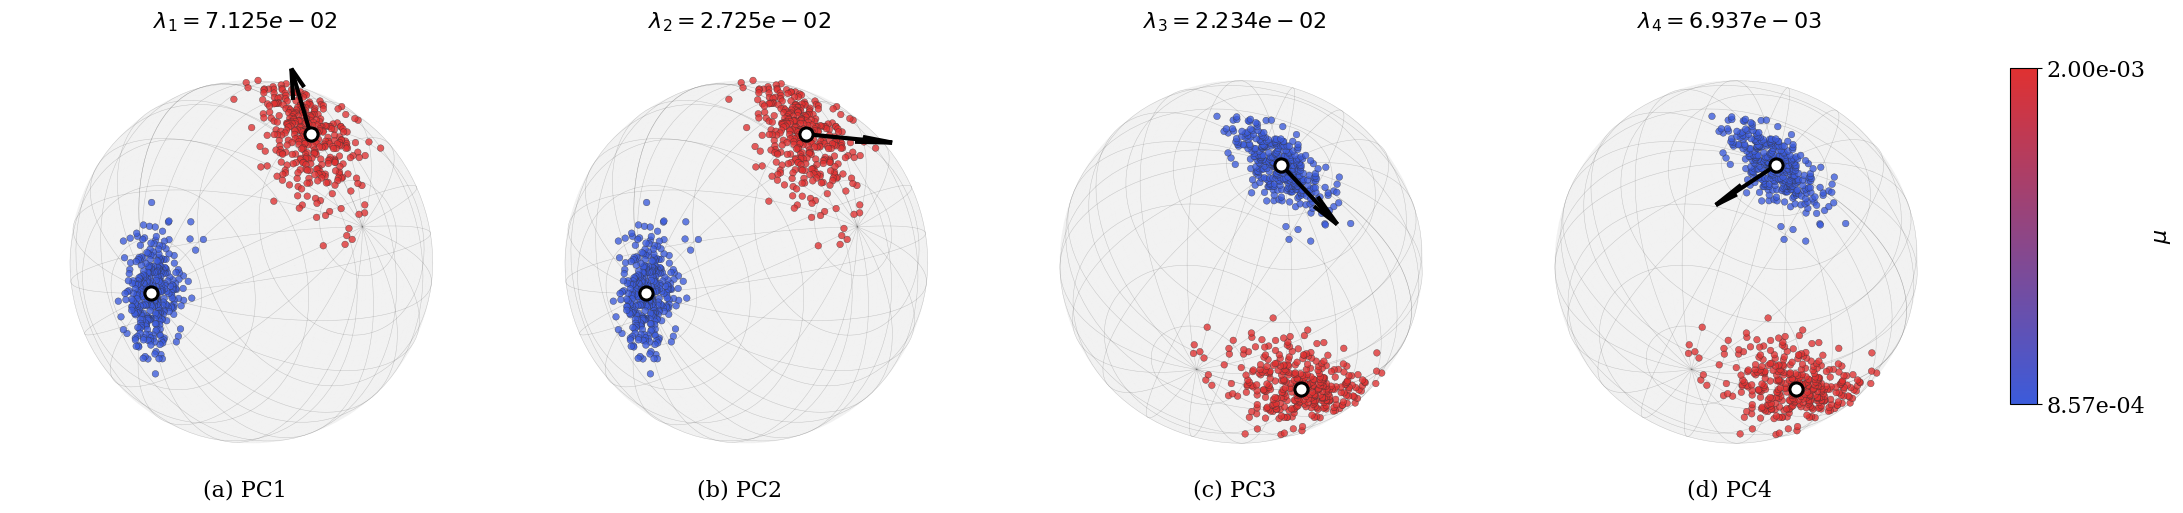

In [ ]:
# In Jupyter, this forces a static/non-interactive output:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.colors import (
    LinearSegmentedColormap,
    Normalize,
)
from matplotlib.cm import ScalarMappable

# Paper settings

# Select the fourth diffusion time from the fitted RiePCA result.
RIEPCA_PAPER_T = 0.15

PAPER_FONT_SIZE = 16
PAPER_FONT_FAMILY = "serif"

BLUE_CLUSTER_LABEL = 0

"""
PC_COLORS = [
    "#009E73",  # PC1: green
    "#0072B2",  # PC2: blue
    "#C49A00",  # PC3: dark golden yellow
    "#CC79A7",  # PC4: purple
]
"""
PC_COLORS = [
    "black",  # PC1
    "black",  # PC2
    "black",  # PC3
    "black",  # PC4
]

# Low mu = blue; high mu = red.
MU_CMAP = LinearSegmentedColormap.from_list(
    "mu_blue_red",
    ["#3B5BDB", "#E03131"],
)


def normalize_vector(vector):
    vector = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(vector)

    if norm < 1.0e-12:
        raise ValueError("Cannot normalize a zero vector.")

    return vector / norm


def direction_to_view(direction):
    """Convert a camera direction into Matplotlib elevation/azimuth."""
    direction = normalize_vector(direction)

    azimuth = np.degrees(
        np.arctan2(
            direction[1],
            direction[0],
        )
    )

    elevation = np.degrees(
        np.arctan2(
            direction[2],
            np.hypot(
                direction[0],
                direction[1],
            ),
        )
    )

    return elevation, azimuth


def draw_paper_sphere(ax, radius=1.0):
    """Draw a faint sphere and wireframe on a white background."""

    u = np.linspace(0.0, 2.0 * np.pi, 90)
    v = np.linspace(0.0, np.pi, 50)

    sphere_x = radius * np.outer(
        np.cos(u),
        np.sin(v),
    )

    sphere_y = radius * np.outer(
        np.sin(u),
        np.sin(v),
    )

    sphere_z = radius * np.outer(
        np.ones_like(u),
        np.cos(v),
    )

    ax.plot_surface(
        sphere_x,
        sphere_y,
        sphere_z,
        color="lightgray",
        alpha=0.15,
        linewidth=0,
        shade=False,
        antialiased=True,
        zorder=0,
    )

    ax.plot_wireframe(
        sphere_x,
        sphere_y,
        sphere_z,
        rstride=5,
        cstride=5,
        color="0.35",
        linewidth=0.35,
        alpha=0.30,
        zorder=1,
    )


def finish_paper_sphere_axes(
    ax,
    elevation,
    azimuth,
    target_point,
    desired_screen_angle,
    radius=1.0,
):
    """
    Rotate the view so target_point appears at a requested screen angle.

    desired_screen_angle:
        -45 degrees = bottom-right
        +45 degrees = top-right
    """

    limit = 1.08 * radius

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_box_aspect((1, 1, 1), zoom=1.40)

    # First project the target with zero roll.
    ax.view_init(
        elev=elevation,
        azim=azimuth,
        roll=0.0,
    )

    projection_matrix = ax.get_proj()

    target_x, target_y, _ = proj3d.proj_transform(
        target_point[0],
        target_point[1],
        target_point[2],
        projection_matrix,
    )

    origin_x, origin_y, _ = proj3d.proj_transform(
        0.0,
        0.0,
        0.0,
        projection_matrix,
    )

    dx = target_x - origin_x
    dy = target_y - origin_y

    if np.hypot(dx, dy) < 1.0e-10:
        raise ValueError(
            "The camera is looking almost directly at the red-cluster "
            "center, so its screen position cannot be controlled by roll."
        )

    current_screen_angle = np.degrees(
        np.arctan2(dy, dx)
    )

    camera_roll = (
        desired_screen_angle
        - current_screen_angle
        + 180.0
    ) % 360.0 - 180.0

    ax.view_init(
        elev=elevation,
        azim=azimuth,
        roll=camera_roll,
    )

    ax.set_proj_type("persp")
    ax.grid(False)
    ax.set_axis_off()
    ax.set_facecolor("white")

    return camera_roll


def plot_riepca_pc_fields_static(
    result,
    t,
    n_modes=4,
    display_max_length=0.35,
    marker_size=23,
    marker_alpha=0.78,
):
    available_t_values = np.asarray(
        result.t_values,
        dtype=float,
    )

    matching_indices = np.flatnonzero(
        np.isclose(
            available_t_values,
            float(t),
        )
    )

    if matching_indices.size == 0:
        raise ValueError(
            f"t={t:g} is not available. "
            f"Choose one of {available_t_values.tolist()}."
        )

    time_index = int(matching_indices[0])
    t = float(available_t_values[time_index])

    references = np.asarray(
        result.reference_points_dict[t],
        dtype=float,
    )

    fields = np.asarray(
        result.pc_fields_dict[t],
        dtype=float,
    )

    eigenvalues = np.asarray(
        result.evals_dict[t],
        dtype=float,
    )

    n_modes = min(
        n_modes,
        fields.shape[-1],
        len(eigenvalues),
        4,
    )

    mu_array = np.asarray(mu, dtype=float)
    labels_array = np.asarray(labels)

    # Unweighted principal vector fields
    pc_fields = [
        fields[..., j]
        for j in range(n_modes)
    ]

    # Identify the red cluster:
    # Since high mu is mapped to red, select points having max(mu).

    red_mask = np.isclose(
        mu_array,
        np.max(mu_array),
    )

    red_cluster_center = normalize_vector(
        np.mean(
            data_points[red_mask],
            axis=0,
        )
    )

    # Start with the camera direction used in the Plotly figure.
    camera_direction = normalize_vector(
        [0, 1.45, 1.90]
    )

    # Make sure the camera is on the red cluster's hemisphere.
    if np.dot(
        camera_direction,
        red_cluster_center,
    ) < 0.0:
        camera_direction = -camera_direction

    camera_elevation, camera_azimuth = direction_to_view(
        camera_direction
    )

    # Point-mass colors
    mu_min = float(np.min(mu_array))
    mu_max = float(np.max(mu_array))

    if np.isclose(mu_min, mu_max):
        mu_norm = Normalize(
            vmin=mu_min - 0.5,
            vmax=mu_max + 0.5,
        )
    else:
        mu_norm = Normalize(
            vmin=mu_min,
            vmax=mu_max,
        )

    # Figure
    plt.rcParams.update({
        "font.size": PAPER_FONT_SIZE,
        "font.family": PAPER_FONT_FAMILY,
        "axes.titlesize": PAPER_FONT_SIZE,
    })

    fig = plt.figure(
        figsize=(22, 5.8),
        facecolor="white",
    )

    axes = [
        fig.add_subplot(
            1,
            n_modes,
            j + 1,
            projection="3d",
            # Honor the explicit zorders below so arrows and tail markers
            # remain above the observations.
            computed_zorder=False,
        )
        for j in range(n_modes)
    ]

    # Set final panel positions before computing projected camera angles.
    fig.subplots_adjust(
        left=0.01,
        right=0.91,
        bottom=0.03,
        top=0.84,
        wspace=0.00,
    )

    panel_labels = ["(a)", "(b)", "(c)", "(d)"]
    camera_rolls = []

    for j, ax in enumerate(axes):
        draw_paper_sphere(ax)

        ax.scatter(
            data_points[:, 0],
            data_points[:, 1],
            data_points[:, 2],
            c=mu_array,
            cmap=MU_CMAP,
            norm=mu_norm,
            s=marker_size,
            alpha=marker_alpha,
            edgecolors="0.20",
            linewidths=0.30,
            depthshade=False,
            rasterized=True,
            zorder=2,
        )

        # Independently scale this unweighted PC for display so that later
        # PCs remain visible. Arrow lengths are not comparable across panels.
        pc_field = pc_fields[j]
        largest_norm_in_panel = float(
            np.max(np.linalg.norm(pc_field, axis=1))
        )

        if largest_norm_in_panel > 1.0e-12:
            displayed_vectors = (
                display_max_length
                * pc_field
                / largest_norm_in_panel
            )
        else:
            displayed_vectors = np.zeros_like(pc_field)

        for reference, vector in zip(
            references,
            displayed_vectors,
        ):
            ax.quiver(
                reference[0],
                reference[1],
                reference[2],
                vector[0],
                vector[1],
                vector[2],
                color=PC_COLORS[j],
                linewidth=3,
                arrow_length_ratio=0.4,
                pivot="tail",
                normalize=False,
                zorder=20,
            )

        # White tail markers with borders matching the current PC color.
        ax.scatter(
            references[:, 0],
            references[:, 1],
            references[:, 2],
            color="white",
            marker="o",
            s=90,
            edgecolors=PC_COLORS[j],
            linewidths=2.2,
            depthshade=False,
            zorder=21,
        )


        # Keep only the eigenvalue above the subfigure.
        ax.set_title(
            rf"$\lambda_{{{j + 1}}}={eigenvalues[j]:.3e}$",
            fontsize=PAPER_FONT_SIZE,
            pad=2,
        )

        # Put the subfigure label below the sphere.
        ax.text2D(
            0.5,
            0.05,
            f"{panel_labels[j]} PC{j + 1}",
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=PAPER_FONT_SIZE,
        )

        if j < 2:
            # PC1 and PC2: red at bottom-right.
            desired_red_angle = 65.0
        else:
            # PC3 and PC4: red at top-right.
            desired_red_angle = -65.0

        camera_roll = finish_paper_sphere_axes(
            ax,
            elevation=camera_elevation,
            azimuth=camera_azimuth,
            target_point=red_cluster_center,
            desired_screen_angle=desired_red_angle,
        )

        camera_rolls.append(camera_roll)

    #fig.suptitle(
        #rf"RiePCA principal vector fields at $t={t:g}$",
        #fontsize=PAPER_FONT_SIZE,
        #y=0.96,
    #)

    # Shared mu colorbar
    colorbar_axis = fig.add_axes([
        0.925,
        0.20,
        0.012,
        0.58,
    ])

    scalar_mappable = ScalarMappable(
        norm=mu_norm,
        cmap=MU_CMAP,
    )

    scalar_mappable.set_array([])

    colorbar = fig.colorbar(
        scalar_mappable,
        cax=colorbar_axis,
    )

    colorbar.set_label(
        r"$\mu$",
        fontsize=PAPER_FONT_SIZE,
    )

    unique_mu = np.unique(mu_array)

    if len(unique_mu) <= 6:
        colorbar.set_ticks(unique_mu)
        colorbar.set_ticklabels([
            f"{value:.2e}"
            for value in unique_mu
        ])

    colorbar.ax.tick_params(
        labelsize=PAPER_FONT_SIZE,
    )

    colorbar.outline.set_linewidth(0.8)

    return fig, axes

paper_fig, paper_axes = plot_riepca_pc_fields_static(
    riepca_result,
    t=RIEPCA_PAPER_T,
    n_modes=4,
    display_max_length=0.50,
)

plt.show()

In [ ]:
paper_fig.set_size_inches(22, 6.2)
paper_stem = f"riepca_pc1_pc4_t_{f'{RIEPCA_PAPER_T:g}'.replace('.', 'p')}"
paper_fig.savefig(f"{paper_stem}.pdf", bbox_inches="tight", pad_inches=0.02)
paper_fig.savefig(f"{paper_stem}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)

In [ ]:
!zip -r /content/Sphere.zip /content/

from google.colab import files
files.download('/content/Sphere.zip')

updating: content/ (stored 0%)
updating: content/.config/ (stored 0%)
updating: content/.config/.last_update_check.json (deflated 22%)
updating: content/.config/config_sentinel (stored 0%)
updating: content/.config/.last_survey_prompt.yaml (stored 0%)
updating: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
updating: content/.config/active_config (stored 0%)
updating: content/.config/default_configs.db (deflated 98%)
updating: content/.config/.last_opt_in_prompt.yaml (stored 0%)
updating: content/.config/gce (stored 0%)
updating: content/.config/logs/ (stored 0%)
updating: content/.config/logs/2026.09.04/ (stored 0%)
updating: content/.config/logs/2026.09.04/13.24.31.709670.log (deflated 58%)
updating: content/.config/logs/2026.09.04/13.25.09.479018.log (deflated 57%)
updating: content/.config/logs/2026.09.04/13.24.48.959800.log (deflated 86%)
updating: content/.config/logs/2026.09.04/13.24.51.717993.log (deflated 57%)
updating: content/.c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>